# Modèles non linéaires — `/predict`

**Objectif :** comparer plusieurs modèles non linéaires à la baseline linéaire, avec toutes les variables et avec les
variables réduites, puis vérifier si le feature engineering du notebook 08 les améliore.

Les modèles sont testés avec leurs réglages de référence ; le tuning viendra dans le notebook 10.

## Imports

In [1]:
import numpy as np
import pandas as pd
import shap
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

from agritech.config import SEED
from agritech.modeling import FeatureEngineering, RunInfo, run_experiment
from agritech.notification import notify
from agritech.predict_config import (
    PREDICT_CATEGORICAL,
    PREDICT_CV_FOLDS,
    PREDICT_CV_SHUFFLE,
    PREDICT_DATASET,
    PREDICT_FEATURES,
    PREDICT_FEATURES_DROP,
    PREDICT_NUMERIC,
    PREDICT_ROWS,
    PREDICT_TARGET,
    PREDICT_TEST_SIZE,
)
from agritech.preprocessing import build_pipeline, count_encoded_columns
from agritech.tracking import run_tags, setup_mlflow
from agritech.training_data import feature_types, kfold_cv, load_dataset, protocol_params, split

# Données et protocole

Même protocole que le notebook 07. Le test reste réservé à l'évaluation finale.

In [2]:
df = load_dataset(PREDICT_DATASET, PREDICT_ROWS, PREDICT_FEATURES + [PREDICT_TARGET], non_negative=[PREDICT_TARGET])
X_train, X_test, y_train, y_test = split(df, PREDICT_FEATURES, PREDICT_TARGET, PREDICT_TEST_SIZE, SEED)
cv = kfold_cv(PREDICT_CV_FOLDS, PREDICT_CV_SHUFFLE, SEED)

fichier            : data/processed/predict_training_dataset.csv
lignes x colonnes  : (999769, 10)
valeurs manquantes : 0
valeurs < 0        : 0 (Yield_tons_per_hectare)
total   : 999769 lignes
X_train : (799815, 9)
X_test  : (199954, 9), réservé à l'évaluation finale
y_train : (799815,)
y_test  : (199954,)
validation croisée : KFold(n_splits=5, random_state=42, shuffle=True)


In [3]:
# mêmes tags et mêmes paramètres de protocole pour tous les runs de ce notebook
experience = setup_mlflow("predict")
TAGS = run_tags(service="predict", stage="comparison", notebook="09_predict_nonlinear_models.ipynb")
PARAMS_PROTOCOLE = protocol_params(PREDICT_DATASET, X_train, X_test, PREDICT_TEST_SIZE, SEED, PREDICT_CV_FOLDS, PREDICT_CV_SHUFFLE)

expérience MLflow : oc_p12_agritech_predict


## Jeux de variables

Toutes les variables, ou les variables réduites, sans `Region`, `Weather_Condition` ni `Days_to_Harvest`
(`PREDICT_FEATURES_DROP`).

In [4]:
JEUX_DE_VARIABLES = {
    "all_features": PREDICT_FEATURES,
    "reduced_features": [variable for variable in PREDICT_FEATURES if variable not in PREDICT_FEATURES_DROP],
}

for nom_jeu, variables in JEUX_DE_VARIABLES.items():
    categorielles, numeriques = feature_types(variables, PREDICT_CATEGORICAL, PREDICT_NUMERIC)
    n_colonnes = count_encoded_columns(categorielles, numeriques, X_train)
    print(f"{nom_jeu:16s}: {len(variables)} variables, {n_colonnes} colonnes après encodage")

all_features    : 9 variables, 26 colonnes après encodage
reduced_features: 6 variables, 18 colonnes après encodage


## Modèles comparés

Tous les modèles utilisent le même preprocessing que la régression linéaire, sans optimisation.

| Modèle | Réglages |
|---|---|
| `DecisionTree` | `min_samples_leaf=100` |
| `RandomForest` | 100 arbres, `min_samples_leaf=100` |
| `HistGradientBoosting` | réglages par défaut, sans arrêt anticipé (`early_stopping=False`) |
| `XGBoost` | par défaut : 100 arbres, `learning_rate=0.3`, profondeur 6 |
| `LightGBM` | par défaut : 100 arbres, `learning_rate=0.1`, 31 feuilles |
| `CatBoost` | par défaut : 1 000 itérations, profondeur 6, `learning_rate` automatique ; encodage one-hot commun, sans traitement natif des catégories |

In [5]:
def parametres_du_modele(modele, noms):
    """Valeurs de quelques hyperparamètres d'un modèle, à journaliser dans MLflow."""
    return {nom: modele.get_params()[nom] for nom in noms}


arbre = DecisionTreeRegressor(min_samples_leaf=100, random_state=SEED)
foret = RandomForestRegressor(n_estimators=100, min_samples_leaf=100, n_jobs=-1, random_state=SEED)
boosting = HistGradientBoostingRegressor(early_stopping=False, random_state=SEED)
xgboost = XGBRegressor(random_state=SEED)
lightgbm = LGBMRegressor(random_state=SEED, verbose=-1)
catboost = CatBoostRegressor(random_seed=SEED, verbose=0, allow_writing_files=False)

# nom affiché : (préfixe des runs MLflow, modèle, hyperparamètres enregistrés dans MLflow)
MODELES = {
    "DecisionTree": ("decision_tree", arbre, parametres_du_modele(arbre, ["min_samples_leaf", "max_depth", "random_state"])),
    "RandomForest": (
        "random_forest",
        foret,
        parametres_du_modele(foret, ["n_estimators", "min_samples_leaf", "max_features", "max_depth", "random_state"]),
    ),
    "HistGradientBoosting": (
        "hist_gradient_boosting",
        boosting,
        parametres_du_modele(
            boosting,
            ["max_iter", "learning_rate", "max_leaf_nodes", "max_depth", "min_samples_leaf", "l2_regularization", "early_stopping", "random_state"],
        ),
    ),
    # XGBoost et CatBoost ne renvoient pas leurs valeurs par défaut : elles sont écrites ici
    "XGBoost": ("xgboost", xgboost, {"n_estimators": 100, "learning_rate": 0.3, "max_depth": 6, "random_state": SEED}),
    "LightGBM": (
        "lightgbm",
        lightgbm,
        parametres_du_modele(lightgbm, ["n_estimators", "learning_rate", "num_leaves", "min_child_samples", "random_state"]),
    ),
    "CatBoost": ("catboost", catboost, {"iterations": 1000, "depth": 6, "learning_rate": "auto", "random_seed": SEED}),
}

## Expériences

| Modèle | Toutes les variables | Variables réduites | + interactions pluie, fertilisation, irrigation | + effets selon la culture |
|---|:---:|:---:|:---:|:---:|
| `LinearRegression` (référence) | oui | oui | notebook 08 | notebook 08 |
| `DecisionTree` | oui | oui | — | — |
| `RandomForest`, `HistGradientBoosting`, `XGBoost`, `LightGBM`, `CatBoost` | oui | oui | oui | oui |

- Chaque modèle est comparé sur les deux jeux de variables.
- Les deux familles d'interactions du notebook 08 sont testées sur les cinq modèles d'ensemble, ceux qui passent au
  tuning dans le notebook 10. L'arbre seul, qui n'y passe pas, n'est pas repris.
- La régression linéaire est recalculée pour ses scores par fold, sans nouveau run ; ses interactions ont déjà été
  testées dans le notebook 08.

Soit 22 expériences journalisées : 12 sur les deux jeux de variables, 10 avec interactions.

# Référence linéaire

Recalculée sur les deux jeux de variables pour avoir les scores par fold, sans nouveau run MLflow. Scores identiques au
notebook 07.

In [6]:
reference = {}
for jeu, variables in JEUX_DE_VARIABLES.items():
    categorielles, numeriques = feature_types(variables, PREDICT_CATEGORICAL, PREDICT_NUMERIC)
    print(f"LinearRegression, {jeu}")
    reference[jeu] = run_experiment(LinearRegression(), X_train, y_train, cv, categorielles, numeriques)

LinearRegression, all_features
RMSE 0.5003 ± 0.0009 t/ha | MAE 0.3993 ± 0.0007 t/ha | R² 0.9129 ± 0.0003
Temps moyen d'entraînement : 0.4 s | CV complète : 3 s
LinearRegression, reduced_features
RMSE 0.5003 ± 0.0009 t/ha | MAE 0.3993 ± 0.0007 t/ha | R² 0.9129 ± 0.0003
Temps moyen d'entraînement : 0.3 s | CV complète : 2 s


# Modèles non linéaires

Chaque modèle est évalué sur les deux jeux de variables, avec les mêmes 5 folds ; chaque expérience a son run MLflow.

In [7]:
resultats = {}
for nom, (prefixe, modele, hyperparametres) in MODELES.items():
    for jeu, variables in JEUX_DE_VARIABLES.items():
        categorielles, numeriques = feature_types(variables, PREDICT_CATEGORICAL, PREDICT_NUMERIC)
        resultats[nom, jeu] = run_experiment(
            modele, X_train, y_train, cv, categorielles, numeriques,
            run=RunInfo(f"{prefixe}_{jeu}_cv", jeu, TAGS, PARAMS_PROTOCOLE, hyperparametres),
        )

decision_tree_all_features_cv
RMSE 0.5086 ± 0.0008 t/ha | MAE 0.4059 ± 0.0007 t/ha | R² 0.9100 ± 0.0003
Temps moyen d'entraînement : 2.2 s | CV complète : 12 s
decision_tree_reduced_features_cv
RMSE 0.5075 ± 0.0007 t/ha | MAE 0.4051 ± 0.0006 t/ha | R² 0.9104 ± 0.0003
Temps moyen d'entraînement : 1.5 s | CV complète : 8 s
random_forest_all_features_cv
RMSE 0.5020 ± 0.0009 t/ha | MAE 0.4007 ± 0.0007 t/ha | R² 0.9123 ± 0.0003
Temps moyen d'entraînement : 12.1 s | CV complète : 61 s
random_forest_reduced_features_cv
RMSE 0.5021 ± 0.0009 t/ha | MAE 0.4008 ± 0.0007 t/ha | R² 0.9123 ± 0.0003
Temps moyen d'entraînement : 8.5 s | CV complète : 43 s
hist_gradient_boosting_all_features_cv
RMSE 0.5009 ± 0.0009 t/ha | MAE 0.3997 ± 0.0007 t/ha | R² 0.9127 ± 0.0003
Temps moyen d'entraînement : 3.0 s | CV complète : 16 s
hist_gradient_boosting_reduced_features_cv
RMSE 0.5009 ± 0.0009 t/ha | MAE 0.3997 ± 0.0007 t/ha | R² 0.9127 ± 0.0003
Temps moyen d'entraînement : 2.8 s | CV complète : 14 s
xgboost_al

**Observations :**

- L'arbre de décision est moins bon que la régression linéaire sur les deux jeux ; garder les 3 variables retirées des
  variables réduites dégrade sa RMSE.
- La forêt fait nettement mieux que l'arbre seul, sans rattraper la régression linéaire ; c'est le modèle le plus long
  à entraîner.
- HistGradientBoosting est le meilleur des modèles scikit-learn non linéaires, à moins d'un millième de t/ha de la
  régression linéaire, sans la dépasser, avec des scores quasi identiques sur les deux jeux.
- LightGBM et CatBoost rejoignent HistGradientBoosting, sans dépasser la régression linéaire. XGBoost, avec son
  `learning_rate` par défaut de 0,3, reste au niveau de la forêt, derrière les autres boostings.
- Sur les variables réduites, LightGBM ne change pas ; XGBoost et CatBoost gagnent légèrement, de 0,0002 et 0,0001
  t/ha.

# Comparaison des modèles

Tableau trié par RMSE moyenne.

In [8]:
LIBELLES_JEUX = {"all_features": "toutes les variables", "reduced_features": "variables réduites"}

resumes = {f"LinearRegression — {LIBELLES_JEUX[jeu]}": metriques for jeu, (_, metriques) in reference.items()}
resumes |= {f"{nom} — {LIBELLES_JEUX[jeu]}": metriques for (nom, jeu), (_, metriques) in resultats.items()}
COLONNES = ["cv_rmse_mean", "cv_rmse_std", "cv_mae_mean", "cv_r2_mean", "cv_fit_time_mean", "cv_total_time"]

comparaison = pd.DataFrame(resumes).T[COLONNES].sort_values("cv_rmse_mean")
comparaison.round({"cv_rmse_mean": 4, "cv_rmse_std": 4, "cv_mae_mean": 4, "cv_r2_mean": 4, "cv_fit_time_mean": 1, "cv_total_time": 1})

,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_r2_mean,cv_fit_time_mean,cv_total_time
LinearRegression — variables réduites,0.5003,0.0009,0.3993,0.9129,0.3,1.7
LinearRegression — toutes les variables,0.5003,0.0009,0.3993,0.9129,0.4,2.5
HistGradientBoosting — variables réduites,0.5009,0.0009,0.3997,0.9127,2.8,14.5
HistGradientBoosting — toutes les variables,0.5009,0.0009,0.3997,0.9127,3.0,15.6
LightGBM — variables réduites,0.5009,0.0009,0.3998,0.9127,1.2,6.3
LightGBM — toutes les variables,0.5009,0.0009,0.3998,0.9127,1.3,7.0
CatBoost — variables réduites,0.5009,0.0008,0.3998,0.9127,7.2,36.5
CatBoost — toutes les variables,0.5010,0.0009,0.3999,0.9126,6.9,34.8
XGBoost — variables réduites,0.5020,0.0008,0.4006,0.9123,0.7,3.7
RandomForest — toutes les variables,0.5020,0.0009,0.4007,0.9123,12.1,61.3


In [9]:
non_lineaires = comparaison.drop(index=[f"LinearRegression — {libelle}" for libelle in LIBELLES_JEUX.values()])
meilleur = non_lineaires.index[0]
metriques_lineaire = reference["all_features"][1]
ecart = non_lineaires.loc[meilleur, "cv_rmse_mean"] - metriques_lineaire["cv_rmse_mean"]

print(f"meilleur modèle non linéaire : {meilleur}")
print(f"écart de RMSE moyenne avec la régression linéaire, toutes les variables : {ecart:+.6f} t/ha")
print(f"écart-type de la RMSE entre folds, régression linéaire                  : {metriques_lineaire['cv_rmse_std']:.6f} t/ha")

meilleur modèle non linéaire : HistGradientBoosting — variables réduites
écart de RMSE moyenne avec la régression linéaire, toutes les variables : +0.000545 t/ha
écart-type de la RMSE entre folds, régression linéaire                  : 0.000893 t/ha


**Observations :**

- La régression linéaire reste en tête sur les 5 folds.
- HistGradientBoosting, LightGBM et CatBoost sont à moins d'un millième de t/ha : écart plus petit que l'écart-type entre
  folds, mais toujours du même signe.
- Coût croissant de la régression linéaire à la forêt, sans gain.

# Toutes les variables ou variables réduites

Écart de RMSE fold par fold ; un écart positif signifie que toutes les variables font moins bien que les variables réduites.

In [10]:
# scores par fold de chaque modèle, sur les deux jeux de variables
folds_par_modele = {"LinearRegression": {jeu: folds for jeu, (folds, _) in reference.items()}}
for (nom, jeu), (folds, _) in resultats.items():
    folds_par_modele.setdefault(nom, {})[jeu] = folds

rmse_par_fold = pd.DataFrame(
    {f"{nom} {'toutes' if jeu == 'all_features' else 'réduites'}": folds["rmse"] for nom, par_jeu in folds_par_modele.items() for jeu, folds in par_jeu.items()}
)
rmse_par_fold.round(4)

,LinearRegression toutes,LinearRegression réduites,DecisionTree toutes,DecisionTree réduites,RandomForest toutes,RandomForest réduites,HistGradientBoosting toutes,HistGradientBoosting réduites,XGBoost toutes,XGBoost réduites,LightGBM toutes,LightGBM réduites,CatBoost toutes,CatBoost réduites
fold,,,,,,,,,,,,,,
1,0.4993,0.4993,0.5075,0.5065,0.5007,0.5009,0.4997,0.4998,0.5011,0.5009,0.4998,0.4998,0.4999,0.4999
2,0.4999,0.4999,0.5083,0.5070,0.5017,0.5017,0.5004,0.5004,0.5017,0.5016,0.5005,0.5005,0.5006,0.5005
3,0.4998,0.4998,0.5080,0.5073,0.5017,0.5018,0.5004,0.5004,0.5018,0.5016,0.5005,0.5005,0.5006,0.5005
4,0.5011,0.5011,0.5092,0.5082,0.5028,0.5029,0.5017,0.5017,0.5030,0.5029,0.5017,0.5017,0.5018,0.5017
5,0.5016,0.5016,0.5098,0.5084,0.5032,0.5033,0.5022,0.5022,0.5032,0.5031,0.5021,0.5021,0.5022,0.5021


In [11]:
lignes = []
for nom, par_jeu in folds_par_modele.items():
    ecart_par_fold = par_jeu["all_features"]["rmse"] - par_jeu["reduced_features"]["rmse"]
    lignes.append(
        {
            "modèle": nom,
            "écart moyen toutes − réduites": ecart_par_fold.mean(),
            "écart min": ecart_par_fold.min(),
            "écart max": ecart_par_fold.max(),
            "folds où toutes les variables font mieux": int((ecart_par_fold < 0).sum()),
        }
    )
pd.DataFrame(lignes).set_index("modèle").round(6)

,écart moyen toutes − réduites,écart min,écart max,folds où toutes les variables font mieux
modèle,,,,
LinearRegression,0.000002,-0.000002,0.000011,1
DecisionTree,0.001069,0.000730,0.001344,0
RandomForest,-0.000111,-0.000187,-0.000054,5
HistGradientBoosting,0.000005,-0.000019,0.000020,1
XGBoost,0.000175,0.000090,0.000248,0
LightGBM,0.000002,-0.000009,0.000011,2
CatBoost,0.000095,0.000048,0.000122,0


**Observations :**

- Aucun modèle ne gagne vraiment à garder les 3 variables retirées des variables réduites.
- L'écart est négligeable pour la régression linéaire, HistGradientBoosting et LightGBM, et défavorable sur les
  5 folds pour l'arbre, XGBoost et CatBoost.
- Seule la forêt fait un peu mieux avec toutes les variables, sur les 5 folds, mais l'écart est huit fois plus petit
  que l'écart-type entre folds.

# Feature engineering du notebook 08

Les deux familles d'interactions du notebook 08, reprises à l'identique, sont ajoutées à toutes les variables : pluie,
fertilisation et irrigation croisées entre elles, puis pluie et température propres à chaque culture. On vérifie si
elles aident les cinq modèles d'ensemble, avec leurs réglages de référence et les mêmes 5 folds, sans tuning.

In [12]:
# interactions reprises à l'identique du notebook 08
CULTURES = sorted(df["Crop"].unique())


def ajouter_interactions_eau(X):
    """Ajoute les trois interactions entre pluie, fertilisation et irrigation."""
    X = X.copy()
    fertilisation = X["Fertilizer_Used"].astype(int)
    irrigation = X["Irrigation_Used"].astype(int)
    X["Fertilizer_x_Irrigation"] = fertilisation * irrigation
    X["Rainfall_x_Irrigation"] = X["Rainfall_mm"] * irrigation
    X["Rainfall_x_Fertilizer"] = X["Rainfall_mm"] * fertilisation
    return X


def ajouter_interactions_culture(X):
    """Ajoute, pour chaque culture, la pluie et la température limitées aux lignes de cette culture."""
    X = X.copy()
    for culture in CULTURES:
        est_cette_culture = (X["Crop"] == culture).astype(int)
        X[f"Rainfall_x_{culture}"] = X["Rainfall_mm"] * est_cette_culture
        X[f"Temperature_x_{culture}"] = X["Temperature_Celsius"] * est_cette_culture
    return X


COLONNES_EAU = ["Fertilizer_x_Irrigation", "Rainfall_x_Irrigation", "Rainfall_x_Fertilizer"]
COLONNES_CULTURE = [f"{variable}_x_{culture}" for variable in ["Rainfall", "Temperature"] for culture in CULTURES]

# nom de chaque famille dans MLflow : fonction d'ajout et colonnes ajoutées au début du pipeline
INTERACTIONS = {
    "water_inputs_interactions": FeatureEngineering(ajouter_interactions_eau, COLONNES_EAU),
    "crop_interactions": FeatureEngineering(ajouter_interactions_culture, COLONNES_CULTURE),
}
print(f"interactions pluie, fertilisation, irrigation : {len(COLONNES_EAU)} colonnes")
print(f"effets selon la culture : {len(COLONNES_CULTURE)} colonnes, cultures {CULTURES}")

interactions pluie, fertilisation, irrigation : 3 colonnes
effets selon la culture : 12 colonnes, cultures ['Barley', 'Cotton', 'Maize', 'Rice', 'Soybean', 'Wheat']


In [13]:
# les cinq familles qui passent au tuning dans le notebook 10
MODELES_AVEC_INTERACTIONS = ["RandomForest", "HistGradientBoosting", "XGBoost", "LightGBM", "CatBoost"]
categorielles, numeriques = feature_types(PREDICT_FEATURES, PREDICT_CATEGORICAL, PREDICT_NUMERIC)

resultats_interactions = {}
for nom in MODELES_AVEC_INTERACTIONS:
    prefixe, modele, hyperparametres = MODELES[nom]
    for nom_interactions, interactions in INTERACTIONS.items():
        resultats_interactions[nom, nom_interactions] = run_experiment(
            modele, X_train, y_train, cv, categorielles, numeriques, engineering=interactions,
            run=RunInfo(f"{prefixe}_{nom_interactions}_cv", "all_features", TAGS, PARAMS_PROTOCOLE, hyperparametres),
        )

random_forest_water_inputs_interactions_cv
RMSE 0.5021 ± 0.0009 t/ha | MAE 0.4007 ± 0.0007 t/ha | R² 0.9123 ± 0.0003
Temps moyen d'entraînement : 15.2 s | CV complète : 77 s
random_forest_crop_interactions_cv
RMSE 0.5020 ± 0.0009 t/ha | MAE 0.4006 ± 0.0007 t/ha | R² 0.9123 ± 0.0003
Temps moyen d'entraînement : 18.1 s | CV complète : 92 s
hist_gradient_boosting_water_inputs_interactions_cv
RMSE 0.5010 ± 0.0009 t/ha | MAE 0.3998 ± 0.0007 t/ha | R² 0.9127 ± 0.0003
Temps moyen d'entraînement : 3.0 s | CV complète : 16 s
hist_gradient_boosting_crop_interactions_cv
RMSE 0.5009 ± 0.0009 t/ha | MAE 0.3997 ± 0.0007 t/ha | R² 0.9127 ± 0.0003
Temps moyen d'entraînement : 3.8 s | CV complète : 20 s
xgboost_water_inputs_interactions_cv
RMSE 0.5023 ± 0.0008 t/ha | MAE 0.4009 ± 0.0007 t/ha | R² 0.9122 ± 0.0003
Temps moyen d'entraînement : 0.9 s | CV complète : 5 s
xgboost_crop_interactions_cv
RMSE 0.5023 ± 0.0008 t/ha | MAE 0.4008 ± 0.0007 t/ha | R² 0.9122 ± 0.0003
Temps moyen d'entraînement : 1.0 s 

In [14]:
LIBELLES_INTERACTIONS = {
    "water_inputs_interactions": "+ interactions pluie, fertilisation, irrigation",
    "crop_interactions": "+ effets selon la culture",
}

# écart fold par fold avec le même modèle sans interactions ; un écart négatif signifie que les interactions font mieux
lignes = []
for nom in MODELES_AVEC_INTERACTIONS:
    folds_sans, metriques_sans = resultats[nom, "all_features"]
    variantes = {"toutes les variables": (folds_sans, metriques_sans)}
    variantes |= {LIBELLES_INTERACTIONS[n]: resultats_interactions[nom, n] for n in INTERACTIONS}
    for variante, (folds, metriques) in variantes.items():
        ecart = folds["rmse"] - folds_sans["rmse"]
        lignes.append(
            {
                "modèle": nom,
                "variables": variante,
                "RMSE": metriques["cv_rmse_mean"],
                "MAE": metriques["cv_mae_mean"],
                "R²": metriques["cv_r2_mean"],
                "écart moyen": ecart.mean(),
                "folds améliorés": "—" if variante == "toutes les variables" else int((ecart < 0).sum()),
            }
        )

print(f"régression linéaire, toutes les variables : RMSE {reference['all_features'][1]['cv_rmse_mean']:.6f}")
pd.DataFrame(lignes).set_index(["modèle", "variables"]).round({"RMSE": 6, "MAE": 6, "R²": 5, "écart moyen": 6})

régression linéaire, toutes les variables : RMSE 0.500337


RMSE  \
modèle               variables                                                   
RandomForest         toutes les variables                             0.502018   
                     + interactions pluie, fertilisation, irrigation  0.502113   
                     + effets selon la culture                        0.501988   
HistGradientBoosting toutes les variables                             0.500886   
                     + interactions pluie, fertilisation, irrigation  0.500981   
                     + effets selon la culture                        0.500884   
XGBoost              toutes les variables                             0.502183   
                     + interactions pluie, fertilisation, irrigation  0.502322   
                     + effets selon la culture                        0.502271   
LightGBM             toutes les variables                             0.500924   
                     + interactions pluie, fertilisation, irrigation  0.500983   
                     + effets selon la culture                        0.500953   
CatBoost             toutes les variables                             0.501029   
                     + interactions pluie, fertilisation, irrigation  0.501144   
                     + effets selon la culture                        0.501093   

                                                                           MAE  \
modèle               variables                                                   
RandomForest         toutes les variables                             0.400662   
                     + interactions pluie, fertilisation, irrigation  0.400735   
                     + effets selon la culture                        0.400626   
HistGradientBoosting toutes les variables                             0.399724   
                     + interactions pluie, fertilisation, irrigation  0.399803   
                     + effets selon la culture                        0.399727   
XGBoost              toutes les variables                             0.400759   
                     + interactions pluie, fertilisation, irrigation  0.400912   
                     + effets selon la culture                        0.400836   
LightGBM             toutes les variables                             0.399761   
                     + interactions pluie, fertilisation, irrigation  0.399833   
                     + effets selon la culture                        0.399791   
CatBoost             toutes les variables                             0.399856   
                     + interactions pluie, fertilisation, irrigation  0.399944   
                     + effets selon la culture                        0.399895   

                                                                           R²  \
modèle               variables                                                  
RandomForest         toutes les variables                             0.91230   
                     + interactions pluie, fertilisation, irrigation  0.91227   
                     + effets selon la culture                        0.91231   
HistGradientBoosting toutes les variables                             0.91270   
                     + interactions pluie, fertilisation, irrigation  0.91266   
                     + effets selon la culture                        0.91270   
XGBoost              toutes les variables                             0.91224   
                     + interactions pluie, fertilisation, irrigation  0.91220   
                     + effets selon la culture                        0.91221   
LightGBM             toutes les variables                             0.91268   
                     + interactions pluie, fertilisation, irrigation  0.91266   
                     + effets selon la culture                        0.91267   
CatBoost             toutes les variables                             0.91265   
                     + interactions pluie, fertilisation, irrigation 

**Observations :**

- Les interactions pluie, fertilisation et irrigation dégradent légèrement les cinq modèles, de 0,00006 à 0,00014 t/ha
  en moyenne ; seul LightGBM fait mieux, sur un seul fold.
- Les effets selon la culture ne changent presque rien. La forêt gagne 0,00003 t/ha, sur les 5 folds, soit trente fois
  moins que l'écart-type entre folds ; l'écart est nul pour HistGradientBoosting, et XGBoost, LightGBM et CatBoost
  perdent un peu.
- Aucune variante ne rattrape la régression linéaire : le feature engineering n'apporte pas de gain utile aux
  modèles non linéaires.

# Importance par permutation

Hausse de RMSE quand une variable est mélangée sur le fold de validation.

In [15]:
indices_apprentissage, indices_validation = next(cv.split(X_train))  # fold 1 de la validation croisée
X_apprentissage, y_apprentissage = X_train.iloc[indices_apprentissage], y_train.iloc[indices_apprentissage]
X_validation, y_validation = X_train.iloc[indices_validation], y_train.iloc[indices_validation]

boosting_fold_1 = build_pipeline(boosting, PREDICT_CATEGORICAL, PREDICT_NUMERIC).fit(X_apprentissage, y_apprentissage)
foret_fold_1 = build_pipeline(foret, PREDICT_CATEGORICAL, PREDICT_NUMERIC).fit(X_apprentissage, y_apprentissage)
print(f"apprentissage : {len(X_apprentissage)} lignes | validation : {len(X_validation)} lignes")

apprentissage : 639852 lignes | validation : 159963 lignes


In [16]:
def importance_par_permutation(pipeline):
    """Hausse de RMSE en t/ha sur la validation quand une variable est mélangée, sur 10 répétitions."""
    resultat = permutation_importance(
        pipeline, X_validation, y_validation, scoring="neg_root_mean_squared_error", n_repeats=10, random_state=SEED
    )
    return pd.DataFrame(
        {"hausse_rmse": resultat.importances_mean, "ecart_type": resultat.importances_std}, index=X_validation.columns
    )


importances = pd.concat(
    {"HistGradientBoosting": importance_par_permutation(boosting_fold_1), "RandomForest": importance_par_permutation(foret_fold_1)},
    axis=1,
)
importances.sort_values(("HistGradientBoosting", "hausse_rmse"), ascending=False).round(4)

HistGradientBoosting            RandomForest           
                             hausse_rmse ecart_type  hausse_rmse ecart_type
Rainfall_mm                       1.4008     0.0017       1.4010     0.0016
Fertilizer_Used                   0.6737     0.0017       0.6738     0.0017
Irrigation_Used                   0.4836     0.0016       0.4837     0.0016
Temperature_Celsius               0.0392     0.0003       0.0395     0.0003
Days_to_Harvest                   0.0000     0.0000       0.0001     0.0000
Soil_Type                         0.0000     0.0000       0.0000     0.0000
Region                            0.0000     0.0000       0.0000     0.0000
Crop                              0.0000     0.0000      -0.0000     0.0000
Weather_Condition                -0.0000     0.0000      -0.0000     0.0000

**Observations :**

- `Rainfall_mm` domine, puis `Fertilizer_Used` et `Irrigation_Used` ; `Temperature_Celsius` compte peu.
- `Crop`, `Soil_Type`, `Region`, `Weather_Condition` et `Days_to_Harvest` n'apportent rien.

# Corrélations de Spearman

Corrélation entre chaque variable numérique ou booléenne et le rendement, sur le train.

In [17]:
VARIABLES_SPEARMAN = ["Rainfall_mm", "Temperature_Celsius", "Days_to_Harvest", "Fertilizer_Used", "Irrigation_Used"]

spearman = X_train[VARIABLES_SPEARMAN].astype(float).corrwith(y_train, method="spearman")
spearman.sort_values(key=abs, ascending=False).round(3).rename(f"spearman avec {PREDICT_TARGET}")

Rainfall_mm            0.769
Fertilizer_Used        0.431
Irrigation_Used        0.340
Temperature_Celsius    0.080
Days_to_Harvest       -0.003
Name: spearman avec Yield_tons_per_hectare, dtype: float64

**Observations :**

- Même ordre que la permutation : pluie, fertilisation, irrigation, puis température.
- `Days_to_Harvest` : aucune association.

# SHAP global

Contribution moyenne des variables aux prédictions du boosting, sur un échantillon du fold de validation. Figures :
importance globale, puis sens des effets sur les variables numériques et booléennes.

In [18]:
pipeline_shap = boosting_fold_1  # HistGradientBoosting, le meilleur type de modèle non linéaire, déjà ajusté sur le fold 1

echantillon = X_validation.sample(5000, random_state=SEED)
echantillon_encode = pipeline_shap["preprocessing"].transform(echantillon)

explainer = shap.TreeExplainer(pipeline_shap["model"])
shap_colonnes = explainer.shap_values(echantillon_encode)  # une valeur par ligne et par colonne encodée
valeur_de_base = float(np.ravel(explainer.expected_value)[0])

# retour aux variables d'origine : somme des colonnes one-hot d'une même variable
colonnes = pipeline_shap["preprocessing"].get_feature_names_out()
shap_variables = pd.DataFrame(index=echantillon.index)
for variable in PREDICT_FEATURES:
    appartient = [c == f"numeric__{variable}" or c.startswith(f"categorical__{variable}_") for c in colonnes]
    shap_variables[variable] = shap_colonnes[:, appartient].sum(axis=1)

ecart = np.abs(valeur_de_base + shap_variables.sum(axis=1) - pipeline_shap["model"].predict(echantillon_encode)).max()
print(f"valeur de base : {valeur_de_base:.3f} t/ha | écart max entre base + contributions et prédiction : {ecart:.1e}")

importance_shap = shap_variables.abs().mean().sort_values(ascending=False)
importance_shap.round(4).rename("moyenne de |SHAP| (t/ha)")

valeur de base : 4.650 t/ha | écart max entre base + contributions et prédiction : 1.6e-14


Rainfall_mm            1.1348
Fertilizer_Used        0.7496
Irrigation_Used        0.5989
Temperature_Celsius    0.1231
Days_to_Harvest        0.0013
Soil_Type              0.0010
Crop                   0.0008
Region                 0.0005
Weather_Condition      0.0003
Name: moyenne de |SHAP| (t/ha), dtype: float64

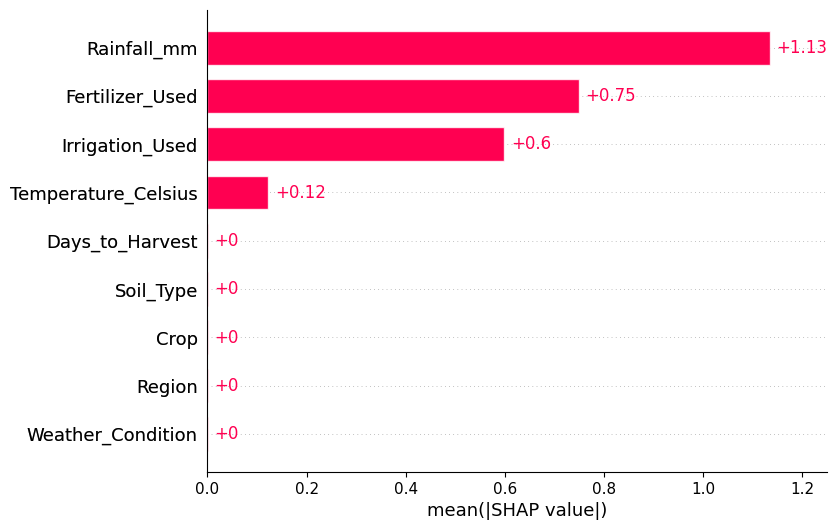

In [19]:
explication = shap.Explanation(
    values=shap_variables.to_numpy(),
    base_values=np.full(len(echantillon), valeur_de_base),
    data=echantillon[PREDICT_FEATURES].to_numpy(),
    feature_names=PREDICT_FEATURES,
)
shap.plots.bar(explication, max_display=9)

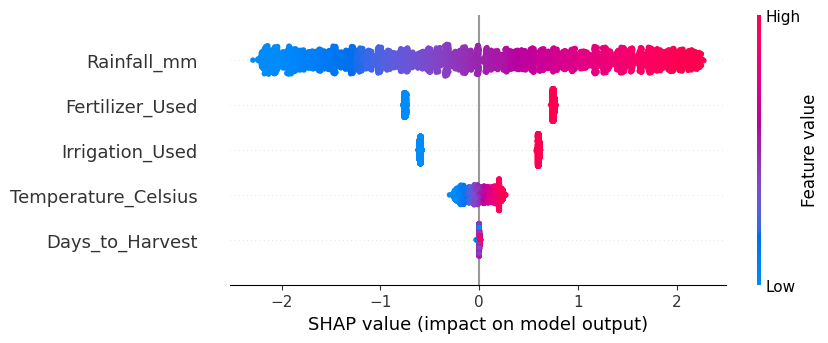

In [20]:
NUMERIQUES_ET_BOOLEENNES = ["Rainfall_mm", "Temperature_Celsius", "Days_to_Harvest", "Fertilizer_Used", "Irrigation_Used"]

explication_numerique = shap.Explanation(
    values=shap_variables[NUMERIQUES_ET_BOOLEENNES].to_numpy(),
    base_values=np.full(len(echantillon), valeur_de_base),
    data=echantillon[NUMERIQUES_ET_BOOLEENNES].astype(float).to_numpy(),
    feature_names=NUMERIQUES_ET_BOOLEENNES,
)
shap.plots.beeswarm(explication_numerique)

**Observations :**

- Même hiérarchie que la permutation et Spearman.
- Plus de pluie, fertilisation, irrigation et température plus élevée poussent la prédiction vers le haut.

# Conclusion

**Observations :**

- la régression linéaire reste la meilleure référence ;
- HistGradientBoosting, LightGBM et CatBoost restent très proches, sans gain sur la RMSE ; XGBoost, la forêt et l'arbre
  seul sont derrière ;
- pluie, fertilisation et irrigation dominent nettement ; la température a un effet plus faible ; les autres variables,
  dont les 3 retirées des variables réduites, n'apportent rien ;
- le feature engineering du notebook 08 n'apporte pas de gain utile aux cinq modèles d'ensemble ;
- prochaine étape : optimiser les modèles et choisir le modèle final (notebook 10).

Le test reste réservé à l'évaluation finale.

In [21]:
notify(
    "Agritech /predict",
    f"Modèles non linéaires terminés — meilleure RMSE CV {comparaison['cv_rmse_mean'].iloc[0]:.4f} ({comparaison.index[0]})",
)